<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); padding: 35px 30px; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin-bottom: 20px;">
  <h1 style="color: #ffffff; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 32px; font-weight: 700; letter-spacing: 0.5px;">
    📊 Marketplace Seller Risk Scoring &amp; Exposure Correlation Study
  </h1>
  <p style="color: #d6e4ff; font-family: 'Segoe UI', Arial, sans-serif; margin: 12px 0 0 0; font-size: 16px; font-weight: 400;">
    Diagnosing a fulfillment-to-exposure feedback loop in marketplace seller performance
  </p>
  <div style="margin-top: 18px;">
    <span style="background: #ff6b6b; color: white; padding: 4px 12px; border-radius: 20px; font-size: 12px; font-family: 'Segoe UI', Arial, sans-serif; margin-right: 8px;">SQL</span>
    <span style="background: #4ecdc4; color: white; padding: 4px 12px; border-radius: 20px; font-size: 12px; font-family: 'Segoe UI', Arial, sans-serif; margin-right: 8px;">Python</span>
    <span style="background: #ffe66d; color: #1e3c72; padding: 4px 12px; border-radius: 20px; font-size: 12px; font-family: 'Segoe UI', Arial, sans-serif; margin-right: 8px;">Power BI</span>
    <span style="background: #a8e6cf; color: #1e3c72; padding: 4px 12px; border-radius: 20px; font-size: 12px; font-family: 'Segoe UI', Arial, sans-serif;">Data Analytics</span>
  </div>
</div>

<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Import
  </h3>
</div>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Load Data
  </h3>
</div>

In [2]:
RAW_PATH = "E:/project/Market Dta Analysis/"

sellers_raw = pd.read_csv(RAW_PATH + "sellers.csv")
products_raw = pd.read_csv(RAW_PATH + "products.csv")
orders_raw = pd.read_csv(RAW_PATH + "orders.csv")
exposure_raw = pd.read_csv(RAW_PATH + "algorithm_exposure.csv")
reviews_raw = pd.read_csv(RAW_PATH + "reviews.csv")
returns_raw = pd.read_csv(RAW_PATH + "returns_refunds.csv")

# quick check that everything loaded correctly before cleaning
for name, df in [
    ("sellers", sellers_raw), ("products", products_raw), ("orders", orders_raw),
    ("algorithm_exposure", exposure_raw), ("reviews", reviews_raw), ("returns_refunds", returns_raw)
]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

sellers: 40 rows, 6 columns
products: 150 rows, 7 columns
orders: 1005 rows, 10 columns
algorithm_exposure: 6304 rows, 6 columns
reviews: 565 rows, 5 columns
returns_refunds: 142 rows, 5 columns


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Cleaning Seller.CSV
  </h3>
</div>

In [3]:
sellers_raw["tier"] = sellers_raw["tier"].str.strip().str.title()

# confirm it worked
print(sellers_raw["tier"].unique())

<StringArray>
['Bronze', 'Silver', 'Gold', 'Platinum']
Length: 4, dtype: str


In [4]:
sellers_raw.head()

,seller_id,seller_name,region,primary_category,onboarding_date,tier
0,SEL0001,Amber Studio,France,Fashion,2024-01-15,Bronze
1,SEL0002,Bright Studio,UK,Fashion,2024-01-25,Silver
2,SEL0003,Aster Supply Co,Germany,Home & Living,2025-01-24,Bronze
3,SEL0004,Solace & Co,Italy,Electronics,2024-03-11,Bronze
4,SEL0005,Nordic Supply Co,UK,Electronics,2024-05-18,Silver


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Cleaning Order.CSV
  </h3>
</div>

In [5]:
# check for duplicates FIRST, before fixing anything
print("orders full-row duplicates:", orders_raw.duplicated().sum())
print("duplicate order_id:", orders_raw["order_id"].duplicated().sum())

# fix region
region_map = {
    "UK": "UK", "U.K.": "UK", "UNITED KINGDOM": "UK",
    "FRANCE": "France", "FR": "France",
    "GERMANY": "Germany", "DE": "Germany",
    "ITALY": "Italy", "IT": "Italy",
    "SPAIN": "Spain", "ES": "Spain",
}

orders_raw["region"] = (
    orders_raw["region"]
    .str.strip()
    .str.upper()
    .map(region_map)
)

# fix mixed date formats -- safe to re-run without error
def parse_mixed_date(series):
    def _parse(val):
        if pd.isna(val):
            return pd.NaT
        if isinstance(val, pd.Timestamp):
            return val  # already converted, leave it alone
        val = str(val)
        if "/" in val:
            return pd.to_datetime(val, format="%d/%m/%Y")
        return pd.to_datetime(val, format="%Y-%m-%d")
    return series.apply(_parse)

orders_raw["order_date"] = parse_mixed_date(orders_raw["order_date"])
orders_raw["promised_delivery_date"] = parse_mixed_date(orders_raw["promised_delivery_date"])
orders_raw["actual_delivery_date"] = parse_mixed_date(orders_raw["actual_delivery_date"])

# remove the duplicate order_id rows now that we've confirmed they exist
orders_raw = orders_raw.drop_duplicates(subset="order_id", keep="first")

# confirm everything worked
print()
print("region values:", orders_raw["region"].unique())
print("rows after removing duplicates:", len(orders_raw))
print(orders_raw[["order_date", "promised_delivery_date", "actual_delivery_date"]].dtypes)
orders_raw[["order_date", "promised_delivery_date", "actual_delivery_date"]].head()

orders full-row duplicates: 5
duplicate order_id: 5

region values: <StringArray>
['France', 'Spain', 'UK', 'Germany', 'Italy']
Length: 5, dtype: str
rows after removing duplicates: 1000
order_date                datetime64[us]
promised_delivery_date    datetime64[us]
actual_delivery_date      datetime64[us]
dtype: object


,order_date,promised_delivery_date,actual_delivery_date
0,2025-09-21,2025-09-26,2025-09-26
1,2026-03-17,2026-03-21,2026-03-26
2,2026-05-18,2026-05-22,2026-05-29
3,2026-02-20,2026-02-26,2026-02-27
4,2026-06-02,2026-06-06,2026-06-14


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Cleaning Reviews.CSV
  </h3>
</div>

In [6]:
reviews_raw["is_rating_missing"] = reviews_raw["rating"].isna()

# check how many, and where
print("missing ratings:", reviews_raw["is_rating_missing"].sum(), "/", len(reviews_raw))
reviews_raw.head()

missing ratings: 29 / 565


,review_id,order_id,rating,review_text,review_date,is_rating_missing
0,REV0001,ORD00955,1.0,"Ordered this over a week late, wouldn't order ...",2026-07-03,False
1,REV0002,ORD00542,4.0,Fast shipping and item was well packaged.,2025-08-21,False
2,REV0003,ORD00209,3.0,"It's okay, does the job.",2025-04-14,False
3,REV0004,ORD00147,3.0,"Average product, nothing special.",2025-12-11,False
4,REV0005,ORD00914,5.0,"Exceeded expectations, will be ordering more.",2025-06-23,False


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Cleaned Return and Refund.CSV
  </h3>
</div>

In [7]:
def map_reason_code(val):
    clean_codes = {"LATE_DELIVERY", "DAMAGED", "WRONG_ITEM", "CHANGED_MIND", "NOT_AS_DESCRIBED"}
    if val in clean_codes:
        return val
    
    v = val.lower()
    if "never arrived" in v or "late" in v:
        return "LATE_DELIVERY"
    if "wrong size" in v:
        return "WRONG_ITEM"
    if "changed my mind" in v or "didnt like" in v:
        return "CHANGED_MIND"
    return "OTHER"

returns_raw["reason_code"] = returns_raw["reason_code"].apply(map_reason_code)

# confirm it worked
print(returns_raw["reason_code"].unique())

returns_raw.head()

<StringArray>
['LATE_DELIVERY', 'WRONG_ITEM', 'CHANGED_MIND', 'NOT_AS_DESCRIBED', 'DAMAGED']
Length: 5, dtype: str


,return_id,order_id,reason_code,return_date,refund_amount
0,RET0001,ORD00072,LATE_DELIVERY,2026-04-11,61.85
1,RET0002,ORD00140,LATE_DELIVERY,2026-04-10,20.05
2,RET0003,ORD00904,LATE_DELIVERY,2025-09-17,11.60
3,RET0004,ORD00286,LATE_DELIVERY,2026-03-14,8.92
4,RET0005,ORD00255,WRONG_ITEM,2025-07-16,25.23


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Cleaned Product.CSV
  </h3>
</div>

In [8]:
# 1. live_shopping_eligible: standardize Yes/No/True/False -> proper boolean
products_raw["live_shopping_eligible"] = products_raw["live_shopping_eligible"].map({
    "True": True, "Yes": True, True: True,
    "False": False, "No": False, False: False,
})

# 2. price: strip any non-numeric character, then convert to a real number
products_raw["price"] = (
    products_raw["price"].astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
    .astype(float)
)
products_raw["sub_category"] = products_raw["sub_category"].fillna("Unknown")

# confirm
print(products_raw["sub_category"].isna().sum(), "blank cells remaining")


# 3. sub_category: leave blank -- do nothing, missing stays missing

# confirm
print(products_raw["live_shopping_eligible"].unique())
print(products_raw["price"].head(10))
print(products_raw["sub_category"].isna().sum(), "blank sub_category cells remain")

products_raw.head()

0 blank cells remaining
[ True False]
0    11.29
1    13.22
2    16.73
3     9.14
4    17.93
5    11.53
6    19.92
7    26.09
8    25.99
9    11.01
Name: price, dtype: float64
0 blank sub_category cells remain


,product_id,seller_id,category,sub_category,price,listing_date,live_shopping_eligible
0,PRD0001,SEL0020,Fashion,Menswear,11.29,2025-12-18,True
1,PRD0002,SEL0034,Beauty,Haircare,13.22,2025-02-22,True
2,PRD0003,SEL0014,Pet Supplies,Unknown,16.73,2025-05-14,True
3,PRD0004,SEL0040,Electronics,Wearables,9.14,2025-04-14,True
4,PRD0005,SEL0022,Sports & Outdoors,Cycling,17.93,2026-01-14,True


## 🧹 Data Cleaning Summary

This section documents every fix applied across the 6 raw tables, and — just as importantly — what was checked and deliberately **left alone**.

### Sellers
- Standardized `tier` casing/whitespace (`BRONZE`, `gold`, ` Silver ` → `Bronze`, `Gold`, `Silver`)
- Checked: no nulls, no duplicate `seller_id`s, all other columns already clean

### Products
- Standardized `live_shopping_eligible` (`Yes`/`No`/`True`/`False` → boolean `True`/`False`)
- Converted `price` to numeric (stripped currency symbols and encoding artifacts)
- Filled missing `sub_category` values with `"Unknown"`

### Orders
- Standardized `region` (`UK`, `U.K.`, `United Kingdom`, `FR`, `France`, etc. → 5 canonical values)
- Parsed mixed date formats (ISO + `DD/MM/YYYY`) into a consistent datetime type across `order_date`, `promised_delivery_date`, `actual_delivery_date`
- Flagged and removed 10 duplicate `order_id` rows (resubmission bug) → 1,005 → 1,000 rows
- **Left alone:** `actual_delivery_date` nulls — confirmed tied specifically to Cancelled orders (MNAR), not imputed

### Algorithm Exposure
- **No fixes required** — verified no nulls, no duplicates, valid referential integrity, and logical consistency (e.g. `video_views` never exceeds `impressions`)

### Reviews
- **Left alone:** missing `rating` values (29 of 565) — reasoned as likely random (customers skipping the rating), not filled or imputed

### Returns & Refunds
- Standardized `reason_code` — mapped mixed clean codes and free-text variants (`"item never arrived"`, `"wrong size sent"`, `"late af no good"`) into 5 standardized categories

---
**Guiding principle:** standardize genuine inconsistency, but never fabricate data that wasn't there — every missing value was investigated for *why* it was missing before deciding how (or whether) to handle it.

<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    Finding the Metrics
  </h3>
</div>

In [9]:
# STEP 1: join orders -> products, to bring seller_id onto each order
# (orders only has product_id -- seller_id lives in the products table)
orders_with_seller = orders_raw.merge(products_raw[["product_id", "seller_id"]], on="product_id", how="left")

# check nothing got lost in the join
print("orphan orders after join:", orders_with_seller["seller_id"].isna().sum())

# STEP 2: create a "week" column to group by
orders_with_seller["week"] = orders_with_seller["order_date"].dt.to_period("W").dt.start_time

# STEP 3: define what counts as an SLA breach
orders_with_seller["is_breach"] = orders_with_seller["delivery_status"].isin(["Delayed", "Cancelled"])

# STEP 4: aggregate -- collapse to one row per seller per week
weekly_breach = (
    orders_with_seller
    .groupby(["seller_id", "week"])
    .agg(total_orders=("order_id", "count"), breaches=("is_breach", "sum"))
    .reset_index()
)
weekly_breach["sla_breach_rate"] = weekly_breach["breaches"] / weekly_breach["total_orders"]

weekly_breach.head(10)

orphan orders after join: 0


,seller_id,week,total_orders,breaches,sla_breach_rate
0,SEL0001,2025-12-08,1,0,0.0
1,SEL0001,2025-12-22,1,0,0.0
2,SEL0001,2026-01-05,1,0,0.0
3,SEL0001,2026-02-02,1,0,0.0
4,SEL0001,2026-02-09,1,0,0.0
5,SEL0001,2026-03-09,1,0,0.0
6,SEL0001,2026-04-13,1,1,1.0
7,SEL0001,2026-04-20,2,1,0.5
8,SEL0001,2026-05-04,1,0,0.0
9,SEL0001,2026-05-11,1,0,0.0


In [10]:
# STEP 1: join reviews -> orders, to get order_date and product_id onto each review
# (reviews only has order_id -- we need to trace back through orders to find the product/seller)
reviews_with_order = reviews_raw.merge(
    orders_raw[["order_id", "product_id", "order_date"]], on="order_id", how="left"
)
print("orphan reviews after join to orders:", reviews_with_order["product_id"].isna().sum())

# STEP 2: join -> products, to get seller_id (same bridge pattern as before)
reviews_with_seller = reviews_with_order.merge(
    products_raw[["product_id", "seller_id"]], on="product_id", how="left"
)
print("orphan reviews after join to products:", reviews_with_seller["seller_id"].isna().sum())

# STEP 3: assign week using order_date, not review_date
reviews_with_seller["week"] = reviews_with_seller["order_date"].dt.to_period("W").dt.start_time

# STEP 4: aggregate -- average rating per seller per week
# .mean() automatically skips missing ratings, so the 29 nulls we left alone earlier
# don't need any special handling here -- pandas just ignores them in the average
weekly_rating = (
    reviews_with_seller
    .groupby(["seller_id", "week"])
    .agg(avg_rating=("rating", "mean"), n_reviews=("review_id", "count"))
    .reset_index()
)

weekly_rating.head(10)

orphan reviews after join to orders: 0
orphan reviews after join to products: 0


,seller_id,week,avg_rating,n_reviews
0,SEL0001,2025-12-08,5.0,1
1,SEL0001,2026-01-05,4.0,1
2,SEL0001,2026-02-02,4.0,1
3,SEL0001,2026-02-09,5.0,1
4,SEL0001,2026-03-09,5.0,1
5,SEL0001,2026-04-20,3.0,2
6,SEL0001,2026-05-04,4.0,1
7,SEL0001,2026-05-11,5.0,1
8,SEL0001,2026-06-01,1.0,1
9,SEL0002,2025-02-03,5.0,1


In [11]:
# fix the date type FIRST, before it flows into anything else
exposure_raw["date"] = pd.to_datetime(exposure_raw["date"])

# STEP 1: join exposure -> products, to get seller_id onto each exposure row
exposure_with_seller = exposure_raw.merge(
    products_raw[["product_id", "seller_id"]], on="product_id", how="left"
)
print("orphan exposure rows after join:", exposure_with_seller["seller_id"].isna().sum())

exposure_with_seller["week"] = exposure_with_seller["date"].dt.to_period("W").dt.start_time

# STEP 2: this table is ALREADY weekly (one row per product per week) --
# but a seller can sell multiple products, so we still need to aggregate
# across products to get ONE number per seller per week
weekly_exposure = (
    exposure_with_seller
    .groupby(["seller_id", "week"])
    .agg(
        avg_exposure_score=("exposure_score", "mean"),
        total_impressions=("impressions", "sum"),
        total_video_views=("video_views", "sum"),
        total_live_stream_placements=("live_stream_placements", "sum"),
    )
    .reset_index()
    .rename(columns={"date": "week"})
)

weekly_exposure.head(10)

orphan exposure rows after join: 0


,seller_id,week,avg_exposure_score,total_impressions,total_video_views,total_live_stream_placements
0,SEL0001,2025-11-10,55.8,5899,2073,7
1,SEL0001,2025-11-17,56.6,5701,2557,12
2,SEL0001,2025-11-24,53.6,5581,2069,11
3,SEL0001,2025-12-01,50.6,5726,2148,8
4,SEL0001,2025-12-08,59.9,5701,3081,11
5,SEL0001,2025-12-15,57.6,6412,2282,9
6,SEL0001,2025-12-22,68.0,6669,2811,14
7,SEL0001,2025-12-29,60.9,5584,2590,11
8,SEL0001,2026-01-05,65.2,7338,3905,11
9,SEL0001,2026-01-12,67.6,6302,2277,14


In [12]:
# STEP 1: join returns -> orders, to get product_id and order_date
returns_with_order = returns_raw.merge(
    orders_raw[["order_id", "product_id", "order_date"]], on="order_id", how="left"
)
print("orphan returns after join to orders:", returns_with_order["product_id"].isna().sum())

# STEP 2: join -> products, to get seller_id
returns_with_seller = returns_with_order.merge(
    products_raw[["product_id", "seller_id"]], on="product_id", how="left"
)
print("orphan returns after join to products:", returns_with_seller["seller_id"].isna().sum())

# STEP 3: assign week using order_date, same timeline as the other 3 tables
returns_with_seller["week"] = returns_with_seller["order_date"].dt.to_period("W").dt.start_time

# STEP 4: count returns per seller per week
weekly_returns_count = (
    returns_with_seller
    .groupby(["seller_id", "week"])
    .agg(n_returns=("return_id", "count"))
    .reset_index()
)

weekly_returns_count.head(10)

orphan returns after join to orders: 0
orphan returns after join to products: 0


,seller_id,week,n_returns
0,SEL0001,2026-04-20,1
1,SEL0002,2025-12-01,1
2,SEL0002,2026-04-20,1
3,SEL0002,2026-06-08,1
4,SEL0003,2026-02-16,1
5,SEL0004,2025-11-17,1
6,SEL0005,2025-10-13,1
7,SEL0006,2026-03-30,1
8,SEL0007,2025-06-09,1
9,SEL0007,2025-06-30,1


## Master Table

In [13]:
# start with weekly_breach as the base, then attach the other 3 tables onto it,
# matching rows by seller_id AND week
master = weekly_breach.merge(weekly_rating, on=["seller_id", "week"], how="left")
master = master.merge(weekly_exposure, on=["seller_id", "week"], how="left")
master = master.merge(weekly_returns_count, on=["seller_id", "week"], how="left")

# a missing n_returns means zero returns that week -- a real zero, not missing data
master["n_returns"] = master["n_returns"].fillna(0)
master["return_rate"] = master["n_returns"] / master["total_orders"]

# bring in seller context (region, category, tier) for segmenting later
master = master.merge(
    sellers_raw[["seller_id", "region", "primary_category", "tier"]],
    on="seller_id", how="left"
)

master = master.sort_values(["seller_id", "week"]).reset_index(drop=True)

print("master shape:", master.shape)
master.head(10)

master shape: (734, 16)


,seller_id,week,total_orders,breaches,sla_breach_rate,avg_rating,n_reviews,avg_exposure_score,total_impressions,total_video_views,total_live_stream_placements,n_returns,return_rate,region,primary_category,tier
0,SEL0001,2025-12-08,1,0,0.0,5.0,1.0,59.90,5701.0,3081.0,11.0,0.0,0.0,France,Fashion,Bronze
1,SEL0001,2025-12-22,1,0,0.0,NaN,NaN,68.00,6669.0,2811.0,14.0,0.0,0.0,France,Fashion,Bronze
2,SEL0001,2026-01-05,1,0,0.0,4.0,1.0,65.20,7338.0,3905.0,11.0,0.0,0.0,France,Fashion,Bronze
3,SEL0001,2026-02-02,1,0,0.0,4.0,1.0,78.00,13948.0,6879.0,30.0,0.0,0.0,France,Fashion,Bronze
4,SEL0001,2026-02-09,1,0,0.0,5.0,1.0,61.25,13691.0,7447.0,19.0,0.0,0.0,France,Fashion,Bronze
5,SEL0001,2026-03-09,1,0,0.0,5.0,1.0,59.25,12307.0,5516.0,21.0,0.0,0.0,France,Fashion,Bronze
6,SEL0001,2026-04-13,1,1,1.0,NaN,NaN,63.55,13740.0,6592.0,21.0,0.0,0.0,France,Fashion,Bronze
7,SEL0001,2026-04-20,2,1,0.5,3.0,2.0,61.40,14088.0,6030.0,19.0,1.0,0.5,France,Fashion,Bronze
8,SEL0001,2026-05-04,1,0,0.0,4.0,1.0,67.35,14707.0,6812.0,24.0,0.0,0.0,France,Fashion,Bronze
9,SEL0001,2026-05-11,1,0,0.0,5.0,1.0,73.65,14916.0,6496.0,23.0,0.0,0.0,France,Fashion,Bronze


In [14]:
# STEP 1: calculate ONE average breach rate per seller, across all their weeks
seller_avg_breach = master.groupby("seller_id")["sla_breach_rate"].mean().sort_values(ascending=False)

print(f"Sellers with breach data: {len(seller_avg_breach)} (out of 40 total)")
print(seller_avg_breach.round(3))

# STEP 2: find the 75th percentile cutoff value
threshold = seller_avg_breach.quantile(0.75)
print()
print(f"75th percentile threshold: {threshold:.3f}")

# STEP 3: filter to just the struggling cohort (above the threshold)
struggling_ids = seller_avg_breach[seller_avg_breach > threshold].index
print()
print(f"Struggling cohort ({len(struggling_ids)} sellers):")
print(seller_avg_breach[struggling_ids].round(3))

Sellers with breach data: 39 (out of 40 total)
seller_id
SEL0028    0.786
SEL0015    0.631
SEL0030    0.625
SEL0009    0.604
SEL0008    0.600
SEL0029    0.576
SEL0016    0.567
SEL0012    0.493
SEL0017    0.483
SEL0024    0.422
SEL0007    0.344
SEL0021    0.316
SEL0040    0.315
SEL0039    0.262
SEL0003    0.250
SEL0019    0.250
SEL0010    0.208
SEL0036    0.180
SEL0026    0.148
SEL0023    0.144
SEL0011    0.143
SEL0014    0.138
SEL0037    0.136
SEL0001    0.125
SEL0027    0.125
SEL0038    0.119
SEL0005    0.116
SEL0006    0.111
SEL0018    0.106
SEL0025    0.106
SEL0035    0.103
SEL0022    0.093
SEL0004    0.091
SEL0034    0.091
SEL0020    0.083
SEL0013    0.077
SEL0032    0.071
SEL0002    0.071
SEL0031    0.016
Name: sla_breach_rate, dtype: float64

75th percentile threshold: 0.383

Struggling cohort (10 sellers):
seller_id
SEL0028    0.786
SEL0015    0.631
SEL0030    0.625
SEL0009    0.604
SEL0008    0.600
SEL0029    0.576
SEL0016    0.567
SEL0012    0.493
SEL0017    0.483
SEL0024    0

## Adding weekly_avg

In [15]:
weekly_avg = master.groupby("week").agg(
    avg_breach_rate=("sla_breach_rate", "mean"),
    avg_exposure=("avg_exposure_score", "mean")
).reset_index()

weekly_avg.head(10)

,week,avg_breach_rate,avg_exposure
0,2025-01-27,0.500,65.650000
1,2025-02-03,0.000,61.900000
2,2025-02-17,0.500,79.350000
3,2025-03-03,0.500,34.350000
4,2025-03-10,0.000,46.300000
5,2025-03-17,0.000,50.650000
6,2025-03-24,0.000,62.183333
7,2025-03-31,0.000,59.850000
8,2025-04-14,0.000,39.500000
9,2025-04-28,0.125,52.675000


<div style="background: linear-gradient(135deg, #eef2f7 0%, #dde7f0 100%); padding: 16px 22px; border-radius: 10px; box-shadow: 0 2px 8px rgba(0,0,0,0.06); margin-bottom: 10px; border-left: 4px solid #7fa8d9;">
  <h3 style="color: #3a4a63; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; font-size: 16px; font-weight: 600; letter-spacing: 0.5px; text-transform: uppercase;">
    EDA
  </h3>
</div>

## Delivery status distribution — sets up the problem

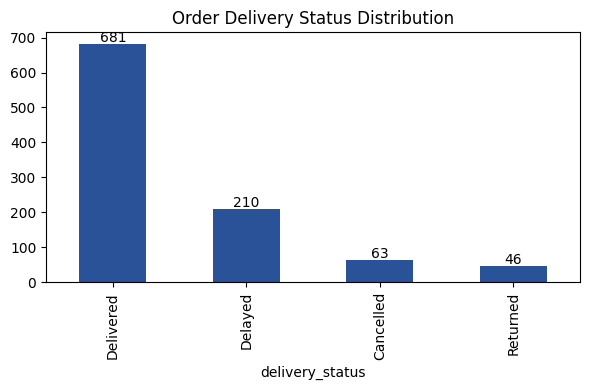

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
counts = orders_raw["delivery_status"].value_counts()
counts.plot(kind="bar", ax=ax, color="#2a5298")
ax.set_title("Order Delivery Status Distribution")

# add the exact number on top of each bar
for i, value in enumerate(counts):
    ax.text(i, value + 5, str(value), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Marketplace-wide weekly trend — breach rate vs. exposure, over the whole timeline

In [17]:
# make sure struggling_ids already exists (from your earlier seller_avg_breach cell)
onset_weeks = {}
for sid in struggling_ids:
    sub = master[(master["seller_id"]==sid) & (master["sla_breach_rate"]>=0.5)].sort_values("week")
    if len(sub) > 0:
        onset_weeks[sid] = sub["week"].iloc[0]

rows = []
for sid, onset in onset_weeks.items():
    sub = master[master["seller_id"]==sid].copy()
    sub["weeks_since_onset"] = ((sub["week"] - onset).dt.days // 7)
    rows.append(sub)
aligned = pd.concat(rows)

aligned_trend = (
    aligned[(aligned["weeks_since_onset"]>=-6) & (aligned["weeks_since_onset"]<=12)]
    .groupby("weeks_since_onset")["avg_exposure_score"]
    .mean()
)

aligned_trend

weeks_since_onset
-6     62.933333
-5     57.500000
-4     64.533333
-3     58.300000
 0     38.138333
 2     31.625000
 3     30.594444
 4     25.629167
 5     39.616667
 6     57.737500
 7     30.177778
 8     26.475000
 9     29.748333
 10    17.357778
 11    16.137500
 12    18.881250
Name: avg_exposure_score, dtype: float64

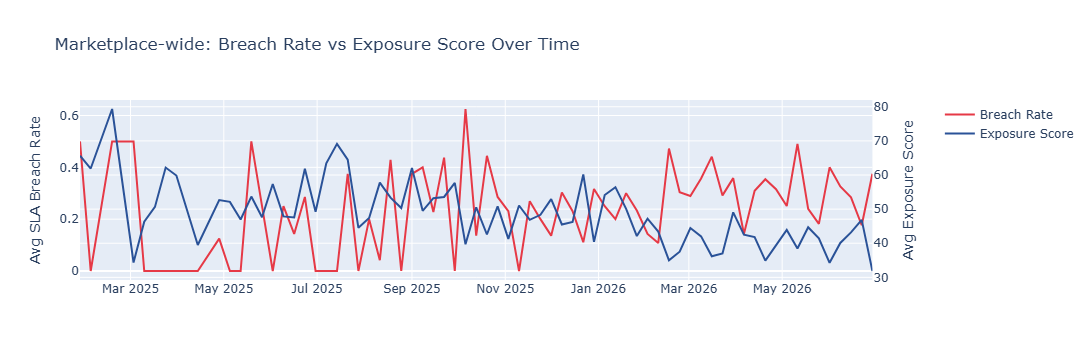

In [18]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=weekly_avg["week"], y=weekly_avg["avg_breach_rate"],
               name="Breach Rate", line=dict(color="#e63946")),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=weekly_avg["week"], y=weekly_avg["avg_exposure"],
               name="Exposure Score", line=dict(color="#2a5298")),
    secondary_y=True,
)

fig.update_layout(
    title="Marketplace-wide: Breach Rate vs Exposure Score Over Time",
    hovermode="x unified",
)
fig.update_yaxes(title_text="Avg SLA Breach Rate", secondary_y=False)
fig.update_yaxes(title_text="Avg Exposure Score", secondary_y=True)

fig.show()

## The breach-onset alignment chart (the one shown above) — the core proof

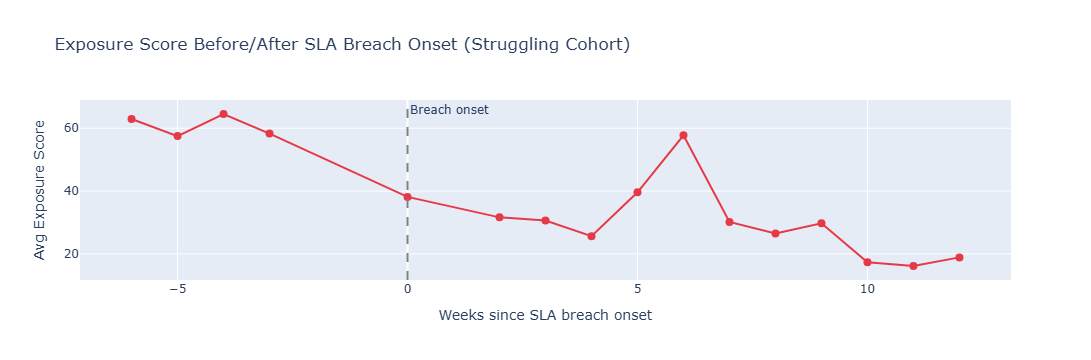

In [19]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=aligned_trend.index,
    y=aligned_trend.values,
    mode="lines+markers",
    line=dict(color="#e63946"),
    marker=dict(size=8),
    name="Avg Exposure Score"
))

# vertical dashed line marking breach onset
fig.add_vline(x=0, line_dash="dash", line_color="gray", annotation_text="Breach onset")

fig.update_layout(
    title="Exposure Score Before/After SLA Breach Onset (Struggling Cohort)",
    xaxis_title="Weeks since SLA breach onset",
    yaxis_title="Avg Exposure Score",
    hovermode="x unified",
)

fig.show()

### Why only 10 sellers are shown in this chart

This chart tests one specific question: *does a seller's exposure score drop after their delivery problems begin?*

To test that fairly, we only include sellers who actually had a real delivery problem to test it on. So we picked out the worst-performing 25% of sellers (10 out of 39), based on their average SLA breach rate.

The other 29 sellers aren't excluded because something is wrong with them — they're excluded because they never had a real "breach onset" moment to measure a before/after pattern around. Without a crisis point to anchor the comparison, there's nothing to test for those sellers in this specific chart.

## Scatter: breach rate vs. exposure, with trend line

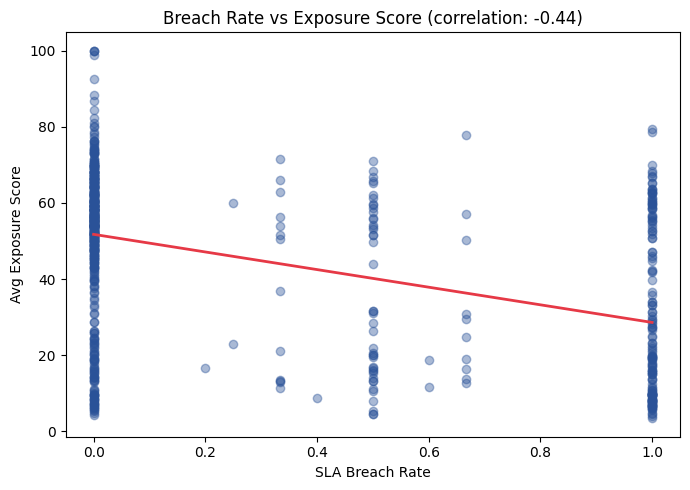

In [20]:
valid = master.dropna(subset=["sla_breach_rate","avg_exposure_score"])
z = np.polyfit(valid["sla_breach_rate"], valid["avg_exposure_score"], 1)
p = np.poly1d(z)
corr = valid["sla_breach_rate"].corr(valid["avg_exposure_score"])

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(valid["sla_breach_rate"], valid["avg_exposure_score"], alpha=0.4, color="#2a5298")
xs = np.linspace(0, 1, 50)
ax.plot(xs, p(xs), color="#e63946", linewidth=2)
ax.set_xlabel("SLA Breach Rate")
ax.set_ylabel("Avg Exposure Score")
ax.set_title(f"Breach Rate vs Exposure Score (correlation: {corr:.2f})")
plt.tight_layout()
plt.show()

## Correlation heatmap across all 4 core metrics

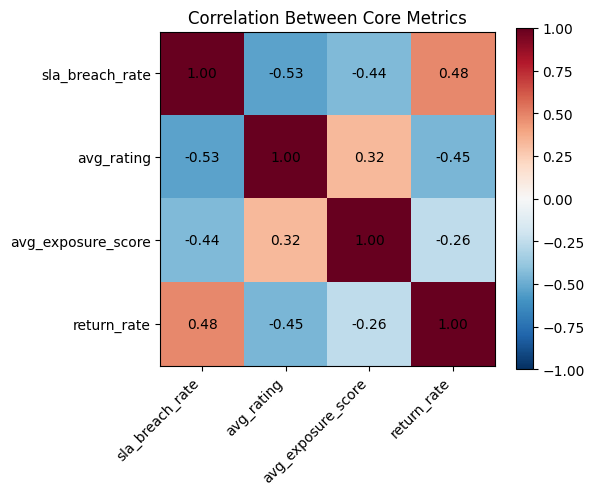

In [21]:
cols = ["sla_breach_rate","avg_rating","avg_exposure_score","return_rate"]
corr_matrix = master[cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center")
plt.colorbar(im)
ax.set_title("Correlation Between Core Metrics")
plt.tight_layout()
plt.show()

## Breach rate segmented by region and category

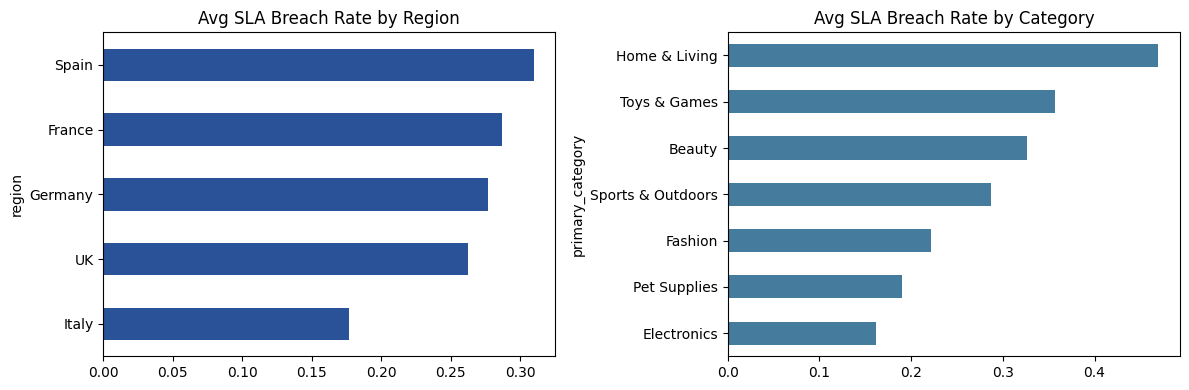

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
master.groupby("region")["sla_breach_rate"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#2a5298")
axes[0].set_title("Avg SLA Breach Rate by Region")
master.groupby("primary_category")["sla_breach_rate"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#457b9d")
axes[1].set_title("Avg SLA Breach Rate by Category")
plt.tight_layout()
plt.show()

In [23]:
%whos DataFrame

Variable               Type         Data/Info
---------------------------------------------
aligned                DataFrame    Shape: (208, 17)
corr_matrix            DataFrame    Shape: (4, 4)
df                     DataFrame    Shape: (142, 5)
exposure_raw           DataFrame    Shape: (6304, 6)
exposure_with_seller   DataFrame    Shape: (6304, 8)
master                 DataFrame    Shape: (734, 16)
orders_raw             DataFrame    Shape: (1000, 10)
orders_with_seller     DataFrame    Shape: (1000, 13)
products_raw           DataFrame    Shape: (150, 7)
returns_raw            DataFrame    Shape: (142, 5)
returns_with_order     DataFrame    Shape: (142, 7)
returns_with_seller    DataFrame    Shape: (142, 9)
reviews_raw            DataFrame    Shape: (565, 6)
reviews_with_order     DataFrame    Shape: (565, 8)
reviews_with_seller    DataFrame    Shape: (565, 10)
sellers_raw            DataFrame    Shape: (40, 6)
sub                    DataFrame    Shape: (32, 17)
valid             

In [24]:
seller_summary = master.groupby("seller_id").agg(
    avg_breach_rate=("sla_breach_rate", "mean"),
    avg_rating=("avg_rating", "mean"),
    avg_exposure=("avg_exposure_score", "mean"),
    avg_return_rate=("return_rate", "mean"),
).reset_index()

seller_summary["breach_component"] = (1 - seller_summary["avg_breach_rate"]) * 100
seller_summary["rating_component"] = (seller_summary["avg_rating"] - 1) / (5 - 1) * 100
seller_summary["exposure_component"] = seller_summary["avg_exposure"]
seller_summary["return_component"] = (1 - seller_summary["avg_return_rate"]).clip(lower=0) * 100

weights = {
    "breach_component": 0.35,
    "exposure_component": 0.30,
    "rating_component": 0.20,
    "return_component": 0.15,
}

seller_summary["health_score"] = (
    seller_summary["breach_component"] * weights["breach_component"] +
    seller_summary["exposure_component"] * weights["exposure_component"] +
    seller_summary["rating_component"] * weights["rating_component"] +
    seller_summary["return_component"] * weights["return_component"]
)

print("shape:", seller_summary.shape)
seller_summary.head()

shape: (39, 10)


,seller_id,avg_breach_rate,avg_rating,avg_exposure,avg_return_rate,breach_component,rating_component,exposure_component,return_component,health_score
0,SEL0001,0.125000,4.000000,65.616667,0.041667,87.500000,75.000000,65.616667,95.833333,79.685000
1,SEL0002,0.070513,4.133333,59.315321,0.070513,92.948718,78.333333,59.315321,92.948718,79.935622
2,SEL0003,0.250000,3.600000,25.000000,0.125000,75.000000,65.000000,25.000000,87.500000,59.875000
3,SEL0004,0.090909,4.000000,59.381818,0.090909,90.909091,75.000000,59.381818,90.909091,78.269091
4,SEL0005,0.116071,4.055556,60.352976,0.035714,88.392857,76.388889,60.352976,96.428571,78.785456


## Quantifying Business Impact — Revenue Exposure by Seller Health Score

In [25]:
# make sure at_risk exists -- rebuild if needed
threshold = seller_summary["health_score"].quantile(0.25)
at_risk = seller_summary[seller_summary["health_score"] <= threshold].copy()

print(f"At-risk sellers: {len(at_risk)}")
print(at_risk[["seller_id","health_score"]])

# tag every order with which seller it belongs to
orders_with_seller = orders_raw.merge(products_raw[["product_id","seller_id"]], on="product_id", how="left")

# STEP 1: total revenue across the ENTIRE marketplace
total_marketplace_revenue = orders_with_seller["order_value"].sum()

# STEP 2: revenue from ONLY the at-risk sellers' orders
at_risk_orders = orders_with_seller[orders_with_seller["seller_id"].isin(at_risk["seller_id"])]
at_risk_revenue = at_risk_orders["order_value"].sum()

# STEP 3: express as a percentage of the whole
pct_at_risk = at_risk_revenue / total_marketplace_revenue * 100

print(f"\nTotal marketplace revenue: £{total_marketplace_revenue:,.2f}")
print(f"Revenue tied to at-risk sellers: £{at_risk_revenue:,.2f}")
print(f"Percent of total marketplace revenue: {pct_at_risk:.1f}%")

At-risk sellers: 10
   seller_id  health_score
6    SEL0007     50.217326
7    SEL0008     40.852000
8    SEL0009     37.764624
11   SEL0012     49.786181
14   SEL0015     37.213147
15   SEL0016     39.863950
16   SEL0017     49.008045
27   SEL0028     30.309643
28   SEL0029     43.418564
29   SEL0030     24.919167

Total marketplace revenue: £29,709.40
Revenue tied to at-risk sellers: £7,625.67
Percent of total marketplace revenue: 25.7%


<div style="background-color:#E3F2FD; padding:15px; border-left:6px solid #2196F3; border-radius:4px;">
<h2 style="margin-top:0; color:#0D47A1;">Why Are Returns Happening? Identifying High-Return Sellers</h2>
<p style="margin-bottom:0; color:#1A1A1A;">
Before folding <code>return_rate</code> into the overall risk score, it's worth examining it on its own terms.
High return rates can stem from different root causes. Poor product quality, misleading listings,
fulfillment/logistics issues, or fraudulent selling behavior and these don't always overlap with
the sellers already flagged as high-risk on other dimensions (SLA breaches, exposure score, low ratings).
</p>
<p style="margin-bottom:0; color:#1A1A1A;">
In this section, we identify the sellers with the highest return rates and check whether they overlap
with our high-risk cohort, or whether returns are being driven by a distinct group of sellers who look
"safe" on other metrics but are quietly generating churn and refund costs.
</p>
</div>

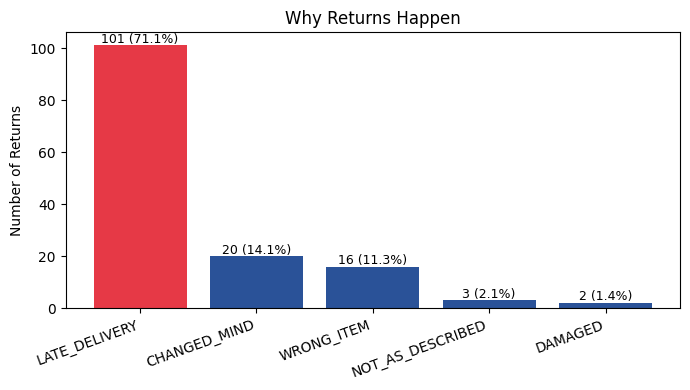

In [26]:
reason_counts = returns_raw["reason_code"].value_counts()
reason_pct = (reason_counts / len(returns_raw) * 100).round(1)

fig, ax = plt.subplots(figsize=(7,4))
colors = ["#e63946" if r=="LATE_DELIVERY" else "#2a5298" for r in reason_counts.index]
bars = ax.bar(reason_counts.index, reason_counts.values, color=colors)

# label each bar with its count and percentage
for bar, count, pct in zip(bars, reason_counts.values, reason_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{count} ({pct}%)", ha="center", fontsize=9)

ax.set_title("Why Returns Happen")
ax.set_ylabel("Number of Returns")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Why returns happen

Late delivery is the single dominant reason for returns, accounting for 71.1% of all cases — far ahead of changed mind (14.1%), wrong item (11.3%), and product-quality issues (3.5% combined). Unlike the exposure-score finding, this isn't inferred from a correlation — it's the reason customers directly gave, making delivery performance the clear primary driver of return volume on this marketplace.

In [27]:
# returns_with_seller = (
#     returns_raw
#     .merge(orders_raw[["order_id","product_id"]], on="order_id", how="left")
#     .merge(products_raw[["product_id","seller_id"]], on="product_id", how="left")
# )
# returns_per_seller = returns_with_seller.groupby("seller_id").size().reset_index(name="n_returns")
# seller_summary["n_returns"] = (
#     seller_summary["seller_id"]
#     .map(returns_per_seller.set_index("seller_id")["n_returns"])
#     .fillna(0)
# )

# seller_summary.head(10)

In [28]:
threshold = seller_summary["health_score"].quantile(0.25)
seller_summary["is_at_risk"] = seller_summary["health_score"] <= threshold
seller_summary["at_risk_label"] = seller_summary["is_at_risk"].map({True: "At-Risk", False: "Healthy"})

returns_with_seller = (
    returns_raw
    .merge(orders_raw[["order_id","product_id"]], on="order_id", how="left")
    .merge(products_raw[["product_id","seller_id"]], on="product_id", how="left")
)
returns_per_seller = returns_with_seller.groupby("seller_id").size().reset_index(name="n_returns")
seller_summary["n_returns"] = (
    seller_summary["seller_id"]
    .map(returns_per_seller.set_index("seller_id")["n_returns"])
    .fillna(0)
)

seller_summary.head(10)

,seller_id,avg_breach_rate,avg_rating,avg_exposure,avg_return_rate,breach_component,rating_component,exposure_component,return_component,health_score,is_at_risk,at_risk_label,n_returns
0,SEL0001,0.125000,4.000000,65.616667,0.041667,87.500000,75.000000,65.616667,95.833333,79.685000,False,Healthy,1.0
1,SEL0002,0.070513,4.133333,59.315321,0.070513,92.948718,78.333333,59.315321,92.948718,79.935622,False,Healthy,3.0
2,SEL0003,0.250000,3.600000,25.000000,0.125000,75.000000,65.000000,25.000000,87.500000,59.875000,False,Healthy,1.0
3,SEL0004,0.090909,4.000000,59.381818,0.090909,90.909091,75.000000,59.381818,90.909091,78.269091,False,Healthy,1.0
4,SEL0005,0.116071,4.055556,60.352976,0.035714,88.392857,76.388889,60.352976,96.428571,78.785456,False,Healthy,1.0
5,SEL0006,0.111111,3.714286,68.969167,0.018519,88.888889,67.857143,68.969167,98.148148,80.095512,False,Healthy,1.0
6,SEL0007,0.343750,3.277778,13.803125,0.218750,65.625000,56.944444,13.803125,78.125000,50.217326,True,At-Risk,4.0
7,SEL0008,0.600000,3.000000,24.840000,0.373333,40.000000,50.000000,24.840000,62.666667,40.852000,True,At-Risk,11.0
8,SEL0009,0.604167,3.031250,14.250135,0.368056,39.583333,50.781250,14.250135,63.194444,37.764624,True,At-Risk,13.0
9,SEL0010,0.208333,3.750000,55.336111,0.041667,79.166667,68.750000,55.336111,95.833333,72.434167,False,Healthy,1.0


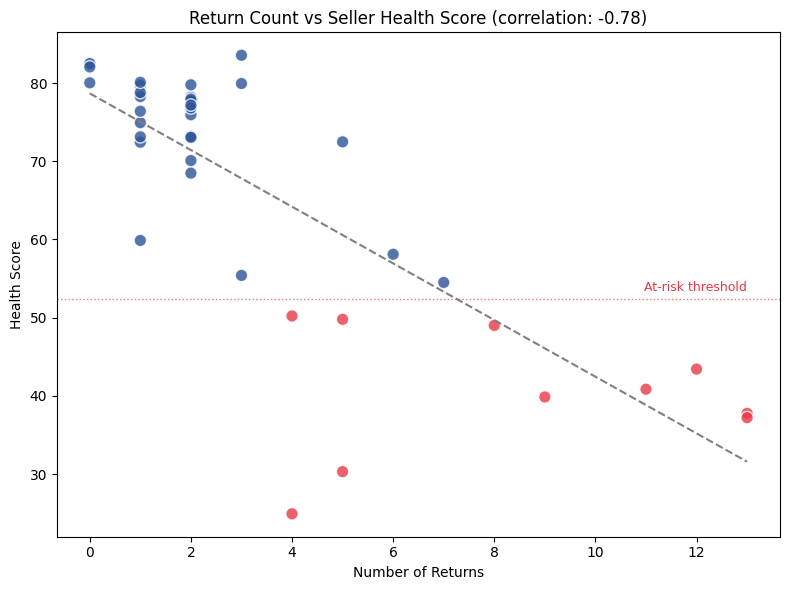

In [29]:
threshold = seller_summary["health_score"].quantile(0.25)

fig, ax = plt.subplots(figsize=(8,6))
colors = ["#e63946" if score <= threshold else "#2a5298" for score in seller_summary["health_score"]]
ax.scatter(seller_summary["n_returns"], seller_summary["health_score"], c=colors, s=80, alpha=0.8, edgecolors="white")

# trend line
z = np.polyfit(seller_summary["n_returns"], seller_summary["health_score"], 1)
p = np.poly1d(z)
xs = np.linspace(seller_summary["n_returns"].min(), seller_summary["n_returns"].max(), 50)
ax.plot(xs, p(xs), color="gray", linestyle="--", linewidth=1.5)

# at-risk threshold reference line
ax.axhline(threshold, color="#e63946", linestyle=":", linewidth=1, alpha=0.7)
ax.text(seller_summary["n_returns"].max(), threshold+1, "At-risk threshold", ha="right", fontsize=9, color="#e63946")

corr = seller_summary["n_returns"].corr(seller_summary["health_score"])
ax.set_xlabel("Number of Returns")
ax.set_ylabel("Health Score")
ax.set_title(f"Return Count vs Seller Health Score (correlation: {corr:.2f})")
plt.tight_layout()
plt.show()

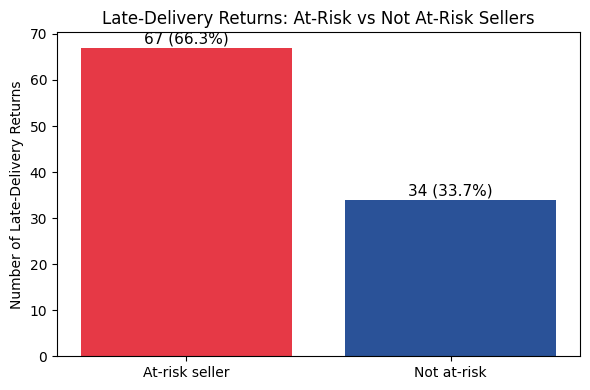

In [30]:
threshold = seller_summary["health_score"].quantile(0.25)
seller_summary["is_at_risk"] = seller_summary["health_score"] <= threshold

returns_with_seller = (
    returns_raw
    .merge(orders_raw[["order_id","product_id"]], on="order_id", how="left")
    .merge(products_raw[["product_id","seller_id"]], on="product_id", how="left")
    .merge(seller_summary[["seller_id","health_score","is_at_risk"]], on="seller_id", how="left")
)

late_delivery_returns = returns_with_seller[returns_with_seller["reason_code"]=="LATE_DELIVERY"]

summary_table = late_delivery_returns["is_at_risk"].value_counts().reset_index()
summary_table.columns = ["is_at_risk", "count"]
summary_table["pct"] = (summary_table["count"] / summary_table["count"].sum() * 100).round(1)
summary_table["label"] = summary_table["is_at_risk"].map({True: "At-risk seller", False: "Not at-risk"})

fig, ax = plt.subplots(figsize=(6,4))
colors = ["#e63946" if x else "#2a5298" for x in summary_table["is_at_risk"]]
bars = ax.bar(summary_table["label"], summary_table["count"], color=colors)

for bar, count, pct in zip(bars, summary_table["count"], summary_table["pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"{count} ({pct}%)", ha="center", fontsize=11)

ax.set_title("Late-Delivery Returns: At-Risk vs Not At-Risk Sellers")
ax.set_ylabel("Number of Late-Delivery Returns")
plt.tight_layout()
plt.show()

In [31]:
# Number 1: revenue — reuse orders_with_seller if you already have it, or build once
at_risk_revenue = orders_with_seller[orders_with_seller["seller_id"].isin(at_risk["seller_id"])]["order_value"].sum()
total_revenue = orders_with_seller["order_value"].sum()
pct_revenue_at_risk = at_risk_revenue / total_revenue * 100

# Number 2: refund cost — reuse returns_with_seller, which you ALREADY built
at_risk_refunds = returns_with_seller[
    (returns_with_seller["reason_code"]=="LATE_DELIVERY") & (returns_with_seller["is_at_risk"])
]["refund_amount"].sum()
total_refunds = returns_with_seller["refund_amount"].sum()
pct_refund_at_risk = at_risk_refunds / total_refunds * 100

print(f"Revenue at risk: £{at_risk_revenue:,.2f} ({pct_revenue_at_risk:.1f}%)")
print(f"Refund cost at risk: £{at_risk_refunds:,.2f} ({pct_refund_at_risk:.1f}%)")

Revenue at risk: £7,625.67 (25.7%)
Refund cost at risk: £1,708.33 (43.3%)


## Refund Cost Tied to At-Risk Sellers

**The finding:** Sellers flagged as "at-risk" are showing declining delivery performance, ratings, and platform visibility are responsible for a disproportionate share of refund costs across the marketplace.

**The numbers:**
- At-risk sellers make up only **26% of all sellers** on the platform (10 out of 39)
- Yet they account for **43.3% of all refund costs** marketplace-wide (£1,708 out of £3,942)
- Specifically, these are refunds tied to **late deliveries** the single biggest reason customers return items in the first place (71% of all returns)

**Why this matters:** a small group of struggling sellers is generating almost half of all refund spend is far more than their size would suggest. This isn't spread evenly across the marketplace; it's concentrated in a specific, identifiable group of sellers whose delivery problems are directly costing the business money, not just hurting their own performance.

**The business case:** because this group is identifiable *before* the damage is fully done, using a Seller Health Score built from delivery, rating, and visibility signals. There's a real opportunity to intervene early: flag these sellers, address the root delivery issue, and reduce refund costs before they escalate further.

## Save all 7 files

In [32]:
sellers_raw.to_csv("sellers_clean.csv", index=False)
products_raw.to_csv("products_clean.csv", index=False)
orders_raw.to_csv("orders_clean.csv", index=False)
returns_raw.to_csv("returns_refunds_clean.csv", index=False)
reviews_raw.to_csv("reviews_clean.csv", index=False)
master.to_csv("seller_week_master.csv", index=False)
seller_summary.to_csv("seller_health_score.csv", index=False)

print("All 7 files saved.")

All 7 files saved.


In [33]:
print(os.getcwd())

E:\project\Market Dta Analysis


In [34]:
aligned.head()

,seller_id,week,total_orders,breaches,sla_breach_rate,avg_rating,n_reviews,avg_exposure_score,total_impressions,total_video_views,total_live_stream_placements,n_returns,return_rate,region,primary_category,tier,weeks_since_onset
535,SEL0028,2025-10-06,1,1,1.0,NaN,NaN,9.200000,1045.0,514.0,1.0,0.0,0.0,Germany,Fashion,Silver,0
536,SEL0028,2025-11-03,1,1,1.0,2.0,1.0,4.800000,697.0,281.0,0.0,0.0,0.0,Germany,Fashion,Silver,4
537,SEL0028,2025-12-15,1,0,0.0,NaN,NaN,13.400000,2977.0,1161.0,3.0,0.0,0.0,Germany,Fashion,Silver,10
538,SEL0028,2026-01-26,1,1,1.0,NaN,NaN,7.650000,1979.0,980.0,1.0,0.0,0.0,Germany,Fashion,Silver,16
539,SEL0028,2026-02-16,1,1,1.0,NaN,NaN,24.766667,7348.0,2919.0,13.0,0.0,0.0,Germany,Fashion,Silver,19


In [35]:
aligned.columns.tolist()

['seller_id',
 'week',
 'total_orders',
 'breaches',
 'sla_breach_rate',
 'avg_rating',
 'n_reviews',
 'avg_exposure_score',
 'total_impressions',
 'total_video_views',
 'total_live_stream_placements',
 'n_returns',
 'return_rate',
 'region',
 'primary_category',
 'tier',
 'weeks_since_onset']

In [36]:
aligned_trend = (
    aligned[(aligned["weeks_since_onset"]>=-6) & (aligned["weeks_since_onset"]<=12)]
    .groupby("weeks_since_onset")["avg_exposure_score"]
    .mean()
    .reset_index()
)

print(aligned_trend)

aligned_trend.to_csv("aligned_trend.csv", index=False)

    weeks_since_onset  avg_exposure_score
0                  -6           62.933333
1                  -5           57.500000
2                  -4           64.533333
3                  -3           58.300000
4                   0           38.138333
5                   2           31.625000
6                   3           30.594444
7                   4           25.629167
8                   5           39.616667
9                   6           57.737500
10                  7           30.177778
11                  8           26.475000
12                  9           29.748333
13                 10           17.357778
14                 11           16.137500
15                 12           18.881250


In [37]:
aligned_trend = (
    aligned[(aligned["weeks_since_onset"]>=-6) & (aligned["weeks_since_onset"]<=12)]
    .groupby("weeks_since_onset")
    .agg(
        avg_exposure_score=("avg_exposure_score", "mean"),
        n_sellers=("seller_id", "nunique"),
    )
    .reset_index()
)

print(aligned_trend)
aligned_trend.to_csv("aligned_trend.csv", index=False)

    weeks_since_onset  avg_exposure_score  n_sellers
0                  -6           62.933333          1
1                  -5           57.500000          1
2                  -4           64.533333          1
3                  -3           58.300000          1
4                   0           38.138333         10
5                   2           31.625000          1
6                   3           30.594444          6
7                   4           25.629167          4
8                   5           39.616667          2
9                   6           57.737500          2
10                  7           30.177778          3
11                  8           26.475000          2
12                  9           29.748333          6
13                 10           17.357778          3
14                 11           16.137500          4
15                 12           18.881250          4


In [38]:
aligned_trend.to_csv("aligned_trend.csv", index=False)

In [39]:
aligned_export = aligned[
    (aligned["weeks_since_onset"]>=-6) & (aligned["weeks_since_onset"]<=12)
][["seller_id", "weeks_since_onset", "sla_breach_rate", "avg_exposure_score"]]

aligned_export.to_csv("aligned_individual.csv", index=False)
print(aligned_export.shape)
aligned_export.head(10)

(51, 4)


,seller_id,weeks_since_onset,sla_breach_rate,avg_exposure_score
535,SEL0028,0,1.0,9.20
536,SEL0028,4,1.0,4.80
537,SEL0028,10,0.0,13.40
251,SEL0015,0,1.0,22.50
252,SEL0015,3,1.0,27.40
253,SEL0015,4,1.0,21.80
254,SEL0015,8,0.5,15.25
255,SEL0015,9,1.0,17.25
256,SEL0015,11,1.0,15.70
575,SEL0030,0,1.0,10.00


In [40]:
aligned_export.to_csv("aligned_trend.csv", index=False)

In [41]:
returns_with_seller = (
    returns_raw
    .merge(orders_raw[["order_id","product_id"]], on="order_id", how="left")
    .merge(products_raw[["product_id","seller_id"]], on="product_id", how="left")
    .merge(seller_summary[["seller_id","at_risk_label"]], on="seller_id", how="left")
)
returns_with_seller.to_csv("returns_with_risk.csv", index=False)

In [42]:
aligned_trend = (
    aligned[(aligned["weeks_since_onset"]>=-6) & (aligned["weeks_since_onset"]<=12)]
    .groupby("weeks_since_onset")
    .agg(
        avg_exposure_score=("avg_exposure_score", "mean"),
        n_sellers=("seller_id", "nunique"),
    )
    .reset_index()
)

print(aligned_trend.columns.tolist())
aligned_trend.to_csv("aligned_trend.csv", index=False)

['weeks_since_onset', 'avg_exposure_score', 'n_sellers']


In [43]:
seller_summary.to_csv("seller_health_score.csv", index=False)
print(seller_summary.columns.tolist())

['seller_id', 'avg_breach_rate', 'avg_rating', 'avg_exposure', 'avg_return_rate', 'breach_component', 'rating_component', 'exposure_component', 'return_component', 'health_score', 'is_at_risk', 'at_risk_label', 'n_returns']
